# DINO feature extraction on BLUSE H5 spectral data

This notebook loads all H5 spectral files from the BLUSE dataset, extracts features using DINO, and analyzes them with UMAP and similarity queries.

In [26]:
import sys
from pathlib import Path

import torch

base_dir = Path('C:/Users/koket/Desktop/BLUSE')
backbone_dir = base_dir / 'backbone'
if backbone_dir.exists():
    sys.path.append(str(base_dir))
    sys.path.append(str(backbone_dir))

model = None

# Prefer the smallest official DINO model from facebookresearch/dino.
# If the repo copy already exists in BLUSE, we try that first; otherwise we use torch.hub.
repo_candidates = [
    base_dir / 'dino',
    base_dir / 'dinov3',
    base_dir / 'facebookresearch_dino',
    Path.home() / 'Documents' / 'spectra_for_features' / 'dinov3',
]
repo_dir = next((p for p in repo_candidates if p.exists()), None)

if repo_dir is not None:
    print('Found local project at:', repo_dir)
    model = torch.hub.load(str(repo_dir), 'dino_vits16', source='local', pretrained=True)
    print('Loaded local DINO model from repo copy.')
else:
    model = torch.hub.load('facebookresearch/dino', 'dino_vits16', pretrained=True)
    print('Loaded official DINO model from torch.hub.')

model.eval()
print(model)


Using cache found in C:\Users\koket/.cache\torch\hub\facebookresearch_dino_main


Loaded official DINO model from torch.hub.
VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, element

In [27]:
from BLUSE_dataset import ImageDataset
import numpy as np
from pathlib import Path
"""
# Load all H5 files and concatenate
h5_dir = base_dir / 'data'
h5_files = sorted(h5_dir.glob('*.h5'))
print(f'Found {len(h5_files)} H5 files:')
for f in h5_files:
    print(f'  - {f.name}')

"""

# Load and concatenate all H5 data

h5_files = ["C:/Users/koket/Desktop/BLUSE/data/mk_sample_hits.h5"]
all_tensors = []
for h5_path in h5_files:
    h5_path = Path(h5_path)
    dataset = ImageDataset(str(h5_path))
    print(f'Loading {h5_path.name}: {len(dataset)} samples')
    for i in range(len(dataset)):
        all_tensors.append(dataset[i])

print(f'\nTotal samples loaded: {len(all_tensors)}')
all_data = torch.stack(all_tensors)
print(f'Concatenated data shape: {all_data.shape}')

# Check actual number of channels in the data
num_channels = all_data.shape[1]
print(f'Number of spectral channels: {num_channels}')

# Check data value ranges
print(f'\nData value ranges:')
print(f'  Min: {all_data.min().item():.6f}')
print(f'  Max: {all_data.max().item():.6f}')
print(f'  Mean: {all_data.mean().item():.6f}')
print(f'  Std: {all_data.std().item():.6f}')

# Normalize each image individually (image-level normalization)
all_data = torch.stack([
    (img - img.min()) / (img.max() - img.min())
    for img in all_data
])
print(f'\nImage-level normalized data ranges: Min={all_data.min():.6f}, Max={all_data.max():.6f}')

# Convert spectral (1, H, W) to RGB for DINO by repeating channels
all_rgb = all_data.repeat(1, 3, 1, 1)
print(f'RGB data shape: {all_rgb.shape}')


Loading mk_sample_hits.h5: 15119 samples

Total samples loaded: 15119
Concatenated data shape: torch.Size([15119, 1, 57, 120])
Number of spectral channels: 1

Data value ranges:
  Min: -1.000000
  Max: 23924104183987306496.000000
  Mean: 1073134488780800.000000
  Std: 16463962560266240.000000

Image-level normalized data ranges: Min=0.000000, Max=1.000000
RGB data shape: torch.Size([15119, 3, 57, 120])


In [28]:

# Extract features using DINO
batch_size = 32
all_features = []

for batch_idx in range(0, len(all_rgb), batch_size):
    batch = all_rgb[batch_idx:batch_idx+batch_size]
    with torch.no_grad():
        out = model(batch)
        all_features.append(out.cpu().numpy())
    print(f'Processed batch {batch_idx//batch_size + 1}/{(len(all_rgb)-1)//batch_size + 1}')

features = np.concatenate(all_features, axis=0)
print(f'Total features extracted: {features.shape}')

# Store sample names
image_names = [f'sample_{i}' for i in range(len(features))]



Processed batch 1/473
Processed batch 2/473
Processed batch 3/473
Processed batch 4/473
Processed batch 5/473
Processed batch 6/473
Processed batch 7/473
Processed batch 8/473
Processed batch 9/473
Processed batch 10/473
Processed batch 11/473
Processed batch 12/473
Processed batch 13/473
Processed batch 14/473
Processed batch 15/473
Processed batch 16/473
Processed batch 17/473
Processed batch 18/473
Processed batch 19/473
Processed batch 20/473
Processed batch 21/473
Processed batch 22/473
Processed batch 23/473
Processed batch 24/473
Processed batch 25/473
Processed batch 26/473
Processed batch 27/473
Processed batch 28/473
Processed batch 29/473
Processed batch 30/473
Processed batch 31/473
Processed batch 32/473
Processed batch 33/473
Processed batch 34/473
Processed batch 35/473
Processed batch 36/473
Processed batch 37/473
Processed batch 38/473
Processed batch 39/473
Processed batch 40/473
Processed batch 41/473
Processed batch 42/473
Processed batch 43/473
Processed batch 44/4

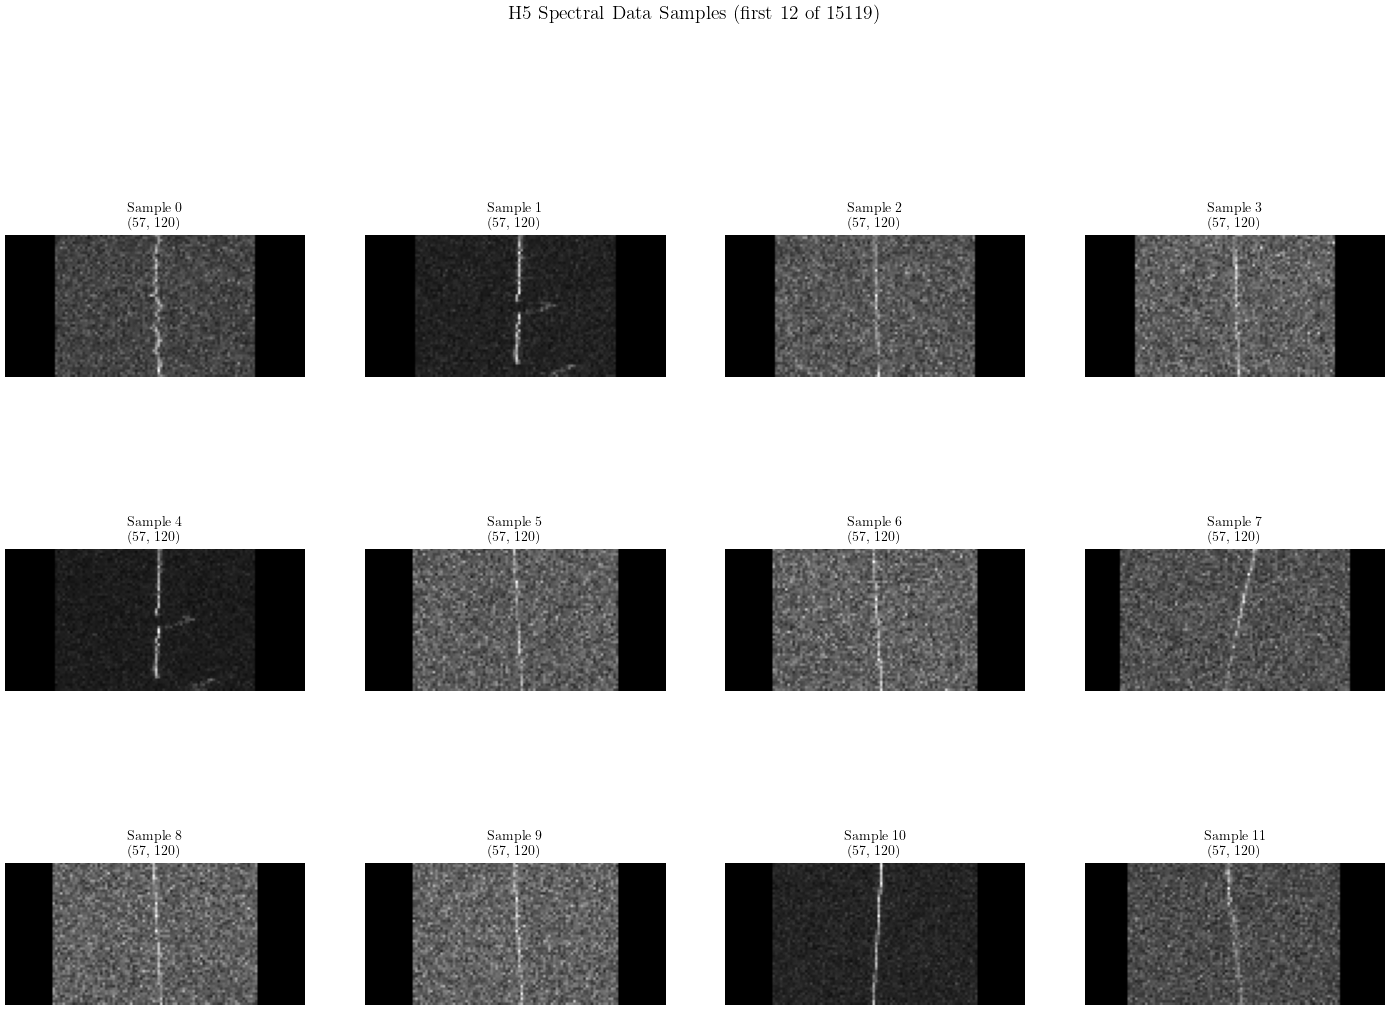

Visualization complete. Total dataset: 15119 samples


In [29]:
import matplotlib.pyplot as plt

# Visualize first 12 loaded H5 samples
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()

for i in range(12):
    img_array = all_data[i].numpy().squeeze()
    axes[i].imshow(img_array, cmap='gray')
    axes[i].set_title(f'Sample {i}\n{img_array.shape}', fontsize=10)
    axes[i].axis('off')

plt.suptitle(f'H5 Spectral Data Samples (first 12 of {len(all_data)})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Visualization complete. Total dataset: {len(all_data)} samples')


Computing UMAP projection...


C:\Users\koket\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting


<Figure size 1050x787.5 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

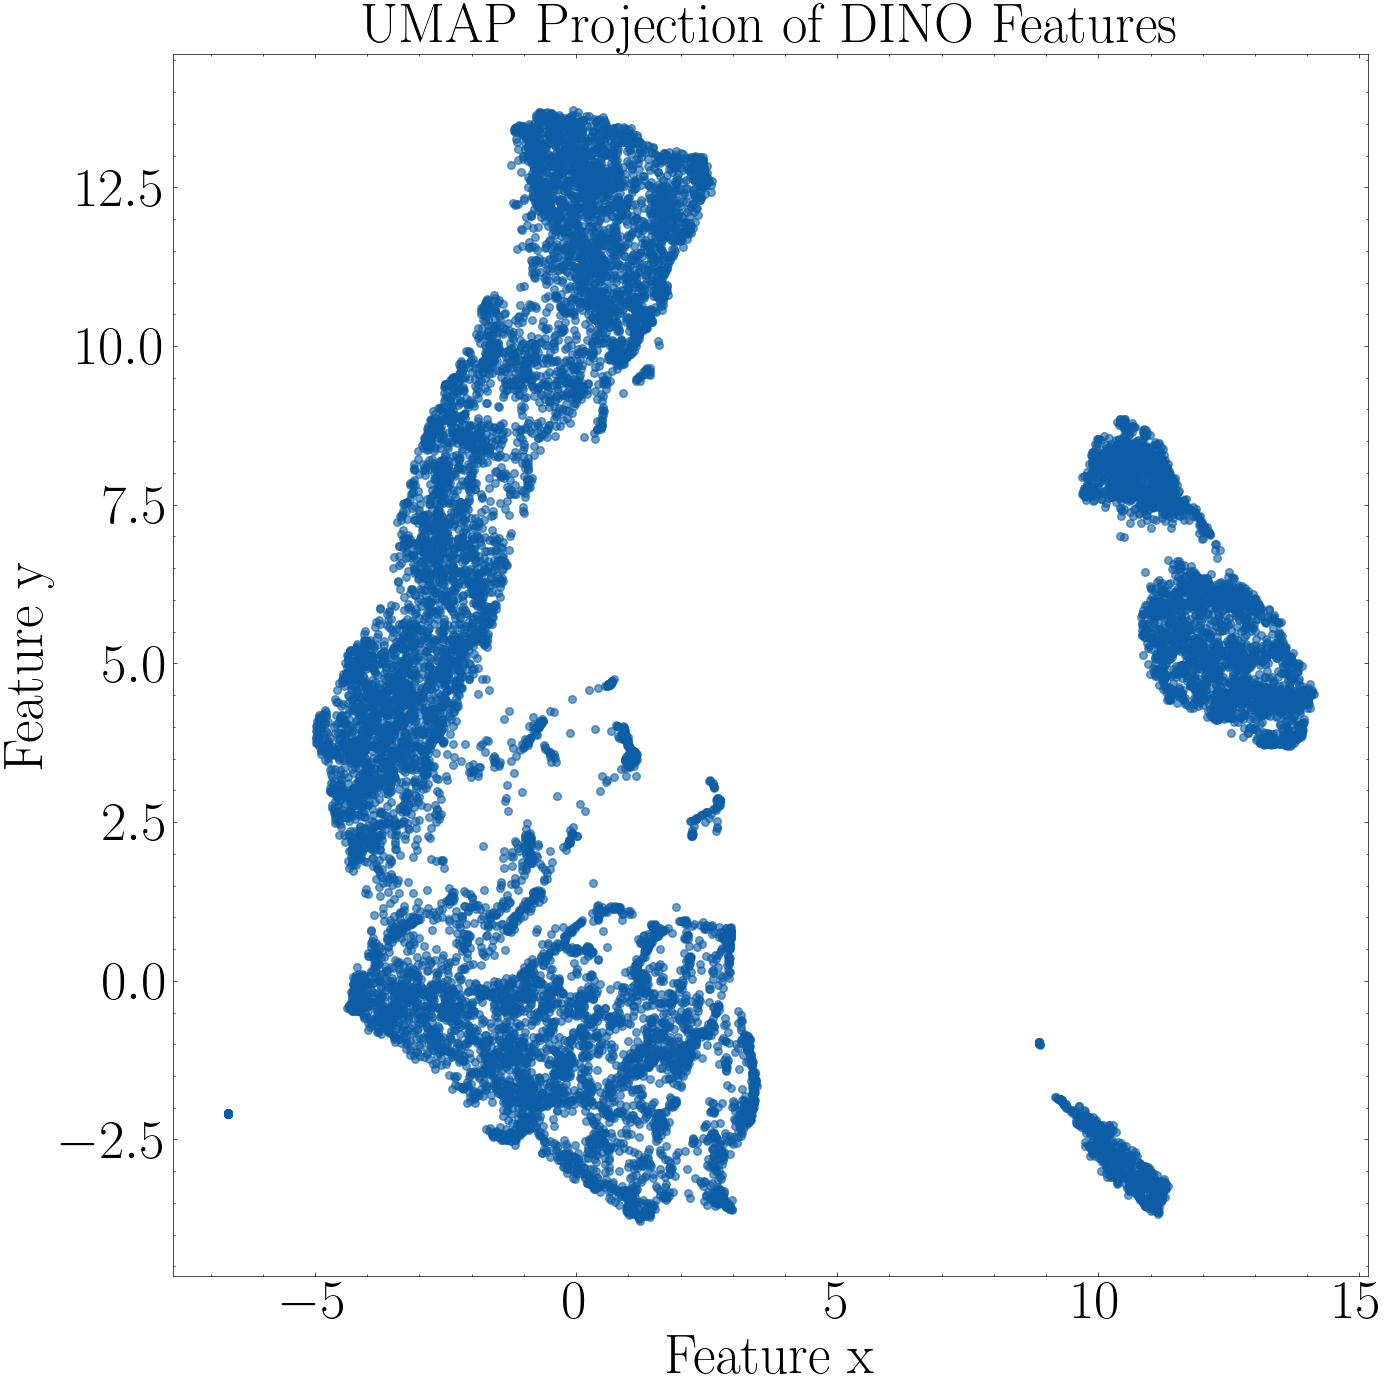

UMAP projection complete for 15119 samples.


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP
import numpy as np
from VISUAL import shade, umap

# Reduce features to 2D using UMAP
print('Computing UMAP projection...')
reducer = UMAP(n_components=2, random_state=42, n_neighbors=min(15, len(features)-1))
features_2d = reducer.fit_transform(features)

# Use VISUAL.py shade function for enhanced scatter plot
# All samples have the same class (no predictions)
predictions = np.zeros(len(features))

# Plot UMAP with enhanced scatter using VISUAL.py
shade(features_2d, 
      predictions,
      numof_class=1,
      name="UMAP Projection of DINO Features",
      size=30,  # Better control over point sizes
      alpha=0.6,
      save=False,
      label=False)

plt.tight_layout()
plt.show()

print(f'UMAP projection complete for {len(features)} samples.')

In [31]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute pairwise cosine similarity
similarity_matrix = cosine_similarity(features)

# Query on first image and a few random samples
for query_idx in [0, 10, 32]:
    similarities = similarity_matrix[query_idx]
    top_indices = np.argsort(similarities)[::-1][:6]
    
    print(f'\nTop 5 similar images to {image_names[query_idx]} (index {query_idx}):')
    rank = 0
    for idx in top_indices:
        if idx != query_idx:
            print(f'  {rank}. {image_names[idx]} (index {idx}) - similarity: {similarities[idx]:.4f}')
            rank += 1

print(f'\nSimilarity matrix shape: {similarity_matrix.shape}')
print(f'Min similarity: {similarity_matrix.min():.4f}, Max: {similarity_matrix.max():.4f}')


Top 5 similar images to sample_0 (index 0):
  0. sample_1043 (index 1043) - similarity: 0.9797
  1. sample_13153 (index 13153) - similarity: 0.9794
  2. sample_1495 (index 1495) - similarity: 0.9787
  3. sample_13321 (index 13321) - similarity: 0.9777
  4. sample_14371 (index 14371) - similarity: 0.9751

Top 5 similar images to sample_10 (index 10):
  0. sample_14140 (index 14140) - similarity: 0.9883
  1. sample_904 (index 904) - similarity: 0.9880
  2. sample_1711 (index 1711) - similarity: 0.9867
  3. sample_12897 (index 12897) - similarity: 0.9863
  4. sample_13097 (index 13097) - similarity: 0.9851

Top 5 similar images to sample_32 (index 32):
  0. sample_31 (index 31) - similarity: 0.9782
  1. sample_35 (index 35) - similarity: 0.9770
  2. sample_1927 (index 1927) - similarity: 0.9769
  3. sample_12776 (index 12776) - similarity: 0.9757
  4. sample_13559 (index 13559) - similarity: 0.9744

Similarity matrix shape: (15119, 15119)
Min similarity: 0.1082, Max: 1.0000


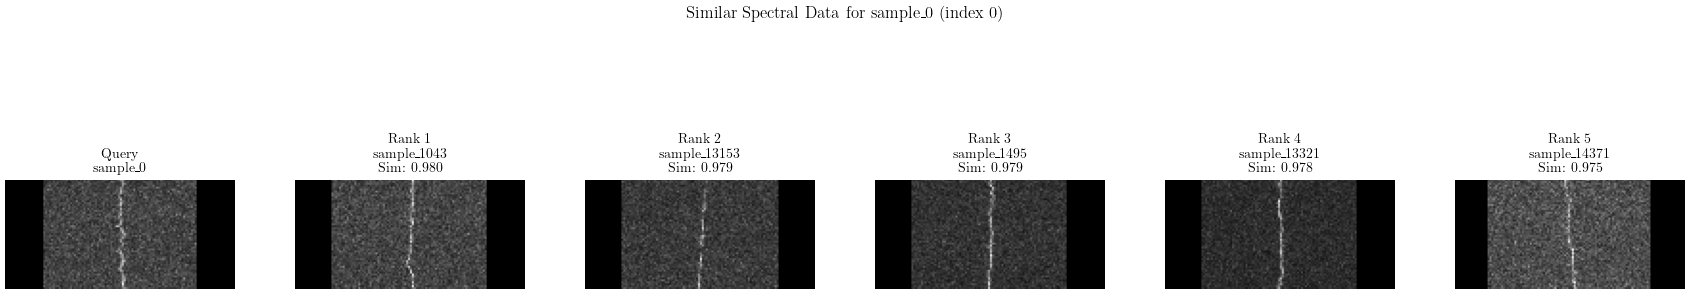

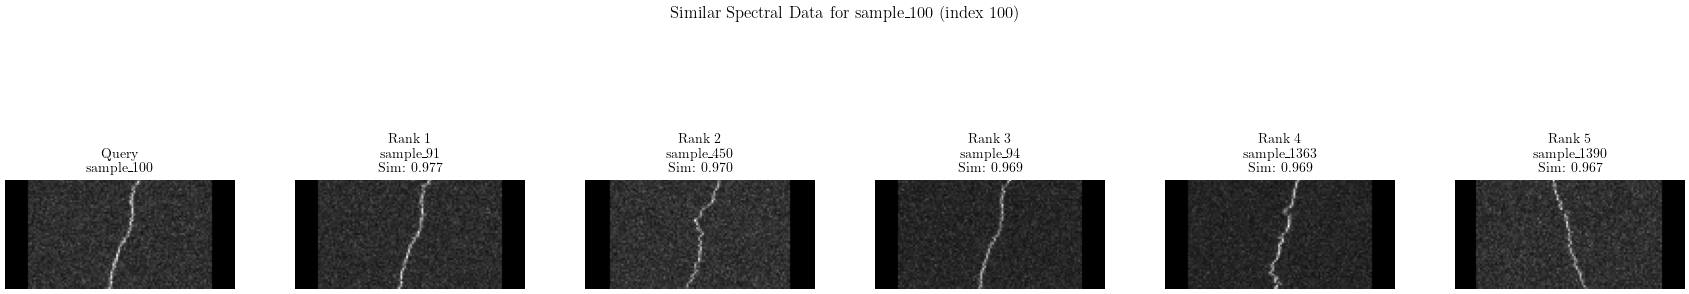

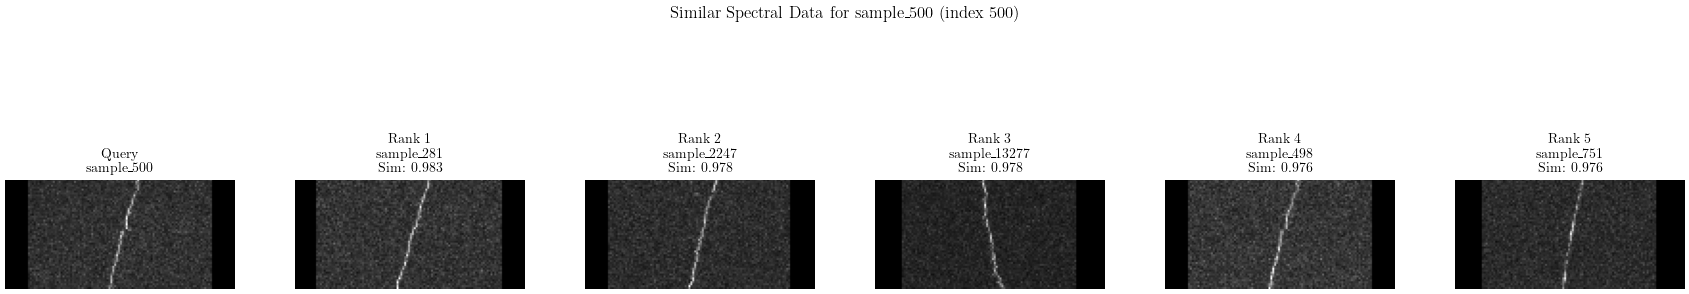

In [32]:
import matplotlib.pyplot as plt

# Visualize spectral samples for similar queries
for query_idx in [0, 100, 500]:
    if query_idx >= len(all_data):
        print(f'Skipping query_idx {query_idx} - dataset has only {len(all_data)} samples')
        continue
    
    similarities = similarity_matrix[query_idx]
    top_indices = np.argsort(similarities)[::-1][:6]
    
    # Get actual similar indices (excluding query itself)
    similar_indices = [idx for idx in top_indices if idx != query_idx][:5]
    
    # Create figure with query spectral + 5 similar spectral
    fig, axes = plt.subplots(1, 6, figsize=(18, 4))
    
    # Display query spectral data
    query_spec = all_data[query_idx].numpy().squeeze()
    axes[0].imshow(query_spec, cmap='gray')
    axes[0].set_title(f'Query\n{image_names[query_idx]}', fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    # Display similar spectral data
    for rank, idx in enumerate(similar_indices):
        sim_spec = all_data[idx].numpy().squeeze()
        axes[rank + 1].imshow(sim_spec, cmap='gray')
        sim_score = similarities[idx]
        axes[rank + 1].set_title(f'Rank {rank+1}\n{image_names[idx]}\nSim: {sim_score:.3f}', fontsize=10)
        axes[rank + 1].axis('off')
    
    plt.suptitle(f'Similar Spectral Data for {image_names[query_idx]} (index {query_idx})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()